Utilizzando il dataset Diabetes, replicare l'esercitazione pratica.
    - Effettuare il data splitting con test_set=0.2 e shuffle=True
    - Effettuare la standarizzazione dei dati (train e test set)
    - Allenare un regressore lineare e calcolare MSE e r2 sul dastaset di testing
    - Valutare la stabilità e le performance medie di un modello di regressione linera utilizzando una CV con scaling dei dati per ogni iterazione
    -Visualizzare graficamente la variabilità dei modelli prodotto dalla cross-validation, confrontando le singole rette di regressione di ogni fold con il modello a split singolo e la retta media risultante.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
data=load_diabetes()
X=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series(data.target,name="target")
display(X)
display(y)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


0      151.0
1       75.0
2      141.0
3      206.0
4      135.0
       ...  
437    178.0
438    104.0
439    132.0
440    220.0
441     57.0
Name: target, Length: 442, dtype: float64

    - Effettuare il data splitting con test_set=0.2 e shuffle=True

In [6]:
X_train,X_test, y_train, y_test=train_test_split(X,y,shuffle=True,test_size=0.2, random_state=42)

    - Effettuare la standarizzazione dei dati (train e test set)

In [7]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

    - Allenare un regressore lineare e calcolare MSE e r2 sul dastaset di testing

In [ ]:
model_standard=LinearRegression()
model_standard.fit(X_train_scaled,y_train)

y_pred_standard=model_standard.predict(X_test_scaled)

mse_standard=mean_squared_error(y_test, y_pred_standard)
r2_standard=r2_score(y_test,y_pred_standard)

print(f"Regressione lineare con StandarScaler:\t MSE={mse_standard:.4f}\tR2={r2_standard:.4f}")


Regressione lineare con StandarScaler:	 MSE=2972.8515	R2=0.4389


In [14]:
feature_to_plot="bmi"
feature_index=X.columns.get_loc(feature_to_plot)
coef_standard=model_standard.coef_[feature_index]
intercept_standard=model_standard.intercept_

    - Valutare la stabilità e le performance medie di un modello di regressione linera utilizzando una CV con scaling dei dati per ogni iterazione

In [13]:
K=5
kf=KFold(n_splits=K,shuffle=True,random_state=42)

In [15]:
all_mse_kfold=[]
all_r2_kfold=[]
kfold_model_coef=[] #serve per il plotting
last_model_kfold=LinearRegression() #lo riprendiamo ad ogni iterazione

for fold_idx, (train_index,test_index) in enumerate(kf.split(X)): #kf.split divide i dati tra train e test, restituisce indici non dati, enumerate aggiunge un contatore 
    X_train_fold,X_test_fold=X.iloc[train_index],X.iloc[test_index]
    y_train_fold,y_test_fold=y.iloc[train_index],y.iloc[test_index]

    fold_scaler=StandardScaler()
    X_train_scaled_fold=fold_scaler.fit_transform(X_train_fold)
    X_test_scaled_fold=fold_scaler.fit_transform(X_test_fold)

    model_fold=LinearRegression()
    model_fold.fit(X_train_scaled_fold,y_train_fold)
    y_pred_fold=model_fold.predict(X_test_scaled_fold)

    all_mse_kfold.append(mean_squared_error(y_test_fold,y_pred_fold))
    all_r2_kfold.append(r2_score(y_test_fold,y_pred_fold))

    kfold_model_coef.append(model_fold.coef_) 
    last_model_kfold=model_fold

#calcoliamo le medie di tutti i valori salvati
mean_mse_kfold=np.mean(all_mse_kfold)
mean_r2_kfold=np.mean(all_r2_kfold)
avg_coef_kfold=np.mean([c[feature_index] for c in kfold_model_coef])
avg_intercept_kfold = last_model_kfold.intercept_

In [16]:
print(f"MSE TEST:\t{mse_standard:.4f}")
print(f"R2 TEST:\t{r2_standard:.4f}"),
print(f"MSE K-Fold:\t{mean_mse_kfold:.4f}")
print(f"R2 K-Fold:\t{mean_r2_kfold:.4f}")

MSE TEST:	2972.8515
R2 TEST:	0.4389
MSE K-Fold:	3141.7956
R2 K-Fold:	0.4564


Il modello spiega circa il 45% di varianza (legermente meno con split standard). La cross validation restituisce risultati simili al test singolo, indicando una discreta stabilità ma senza miglioramenti significativi.
L'MSE leggermente più alto con K-Fold suggerisce che il singolo split era lievemente ottimistico.
L'utilizzo della cross validation è comunque da preferire, anche in presenza di questi modesti miglioramenti, soprattuto con dataset irrilevanti dal punto di vista computazionale

    -Visualizzare graficamente la variabilità dei modelli prodotto dalla cross-validation, confrontando le singole rette di regressione di ogni fold con il modello a split singolo e la retta media risultante.

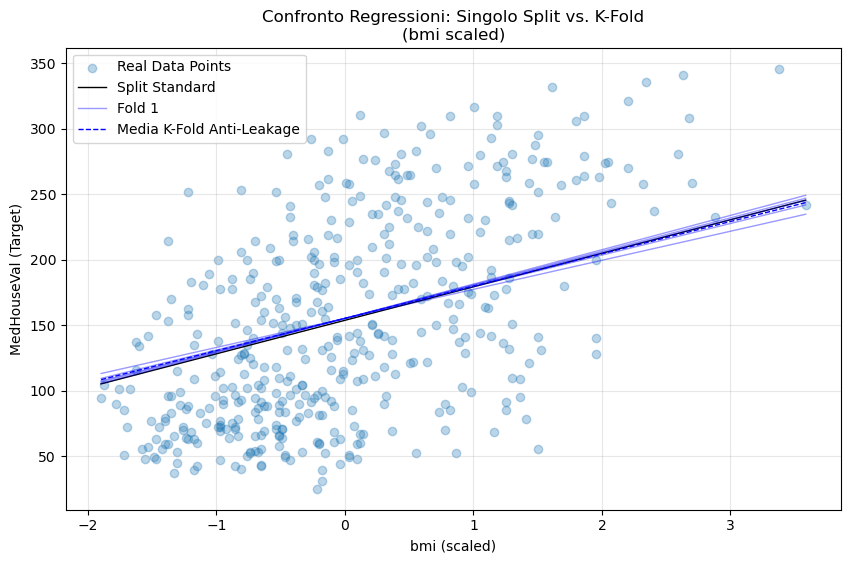

In [17]:
# Ricalcolo dei dati SCALATI per lo Scatter Plot (necessario per l'asse X)
X_plot_feature = StandardScaler().fit_transform(X)[:, feature_index]
y_plot_all = y 

# Coefficienti Split Standard
coef_standard = model_standard.coef_[feature_index]
intercept_standard = model_standard.intercept_

plt.figure(figsize=(10, 6))
# Scatter Plot dei punti reali
plt.scatter(X_plot_feature, y_plot_all, alpha=0.3, label='Real Data Points')
# Range X per tracciare la linea
X_range = np.linspace(X_plot_feature.min(), X_plot_feature.max(), 100)

# Regressione Split Standard
Y_standard = coef_standard * X_range + intercept_standard 
plt.plot(X_range, Y_standard, color='black', linewidth=1, label='Split Standard')

# Regressioni K=5-Fold
for i, coefs in enumerate(kfold_model_coef):
    coef_kfold = coefs[feature_index]
    intercept_kfold = last_model_kfold.intercept_ 
    Y_kfold = coef_kfold * X_range + intercept_kfold 
    
    # Linee individuali dei folds
    plt.plot(X_range, Y_kfold, color='blue', alpha=0.4, linewidth=1, label=f'Fold {i+1}' if i == 0 else "_nolegend_")

# Regressione Media K-Fold
Y_avg_kfold = avg_coef_kfold * X_range + avg_intercept_kfold
plt.plot(X_range, Y_avg_kfold, color='blue', linestyle='--', linewidth=1, label='Media K-Fold Anti-Leakage')

plt.title(f"Confronto Regressioni: Singolo Split vs. K-Fold\n({feature_to_plot} scaled)")
plt.xlabel(f"{feature_to_plot} (scaled)")
plt.ylabel("MedHouseVal (Target)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()